<a href="https://colab.research.google.com/github/jashwanth-suramoni/machine-learning-project/blob/main/Jashwanth_Suramoni_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Transaction Fraud Detection for SafeBank.scv     
##name : Jashwath Suramoni
## Business Problem Understanding

Financial institutions process millions of transactions every day. Among these, a small percentage are fraudulent, causing significant financial losses and reducing customer trust. Manual fraud detection is time-consuming and often fails to identify suspicious transactions in real time. Therefore, SafeBank requires an automated machine learning solution to accurately detect fraudulent transactions while minimizing false alarms.

## Business Objective

Develop a machine learning model that can classify bank transactions as Fraudulent or Legitimate based on transaction-related features. The objective is to improve fraud detection accuracy, reduce financial losses, and enable faster decision-making.

## Business Constraints
Fraudulent transactions are much fewer than legitimate transactions (class imbalance).

False negatives (missing fraud) can lead to financial losses.

False positives (flagging legitimate transactions as fraud) affect customer experience.

The model should provide fast predictions suitable for real-time transaction monitoring.

The solution should be scalable and maintain high accuracy.

## Data Understanding
Load the SafeBank transaction dataset.

Understand the number of records and features.

Identify numerical and categorical variables.

Check for missing values, duplicates, and data types.

Understand the target variable (Fraud or equivalent).

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/YBIFoundation/MLProjectIdeas/main/Transaction%20Fraud%20Detection%20for%20SafeBank.csv")

In [ ]:
df.head()

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1352,1834.26,2023-01-01 13:27:00,Bangalore,Online,89,0.10,Mobile,0
1,1562,3130.03,2023-01-01 04:52:00,Chennai,ATM,44,0.63,Tablet,0
2,1828,3030.78,2023-01-01 13:17:00,Chennai,Bank Transfer,97,0.62,Tablet,1
3,1399,493.04,2023-01-01 21:05:00,Delhi,POS,13,0.24,Mobile,0
4,1740,1298.36,2023-01-01 03:29:00,Chennai,Online,24,0.98,Desktop,0


In [ ]:
df.tail()

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
995,1342,4585.99,2023-01-02 08:31:00,Kolkata,Bank Transfer,67,0.49,Mobile,0
996,1960,1014.59,2023-01-01 07:04:00,Delhi,POS,117,0.88,Tablet,0
997,1308,2500.03,2023-01-02 02:19:00,Mumbai,Online,88,0.57,Mobile,0
998,1194,1804.07,2023-01-03 05:02:00,Hyderabad,Online,53,0.66,Mobile,0
999,1322,908.05,2023-01-01 17:58:00,Chennai,POS,97,0.46,Mobile,0


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.columns

Index(['CustomerID', 'TransactionAmount', 'TransactionTime', 'Location',
       'TransactionType', 'AccountAgeMonths', 'BehaviorScore', 'DeviceUsed',
       'IsFraud'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   TransactionAmount  1000 non-null   float64
 2   TransactionTime    1000 non-null   object 
 3   Location           1000 non-null   object 
 4   TransactionType    1000 non-null   object 
 5   AccountAgeMonths   1000 non-null   int64  
 6   BehaviorScore      1000 non-null   float64
 7   DeviceUsed         1000 non-null   object 
 8   IsFraud            1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,CustomerID,TransactionAmount,AccountAgeMonths,BehaviorScore,IsFraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1503.398000,1997.250540,59.792000,0.548200,0.04600
std,282.614707,1974.282111,33.652537,0.254637,0.20959
min,1003.000000,5.020000,1.000000,0.100000,0.00000
25%,1259.000000,583.137500,33.000000,0.330000,0.00000
50%,1508.000000,1415.500000,59.500000,0.550000,0.00000
75%,1739.000000,2748.712500,89.000000,0.760000,0.00000
max,1997.000000,16445.260000,119.000000,1.000000,1.00000


In [ ]:
df.describe(include='all')

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
count,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1000,1000.00000
unique,NaN,NaN,851,6,4,NaN,NaN,3,NaN
top,NaN,NaN,2023-01-01 16:47:00,Chennai,POS,NaN,NaN,Mobile,NaN
freq,NaN,NaN,4,179,267,NaN,NaN,355,NaN
mean,1503.398000,1997.250540,NaN,NaN,NaN,59.792000,0.548200,NaN,0.04600
std,282.614707,1974.282111,NaN,NaN,NaN,33.652537,0.254637,NaN,0.20959
min,1003.000000,5.020000,NaN,NaN,NaN,1.000000,0.100000,NaN,0.00000
25%,1259.000000,583.137500,NaN,NaN,NaN,33.000000,0.330000,NaN,0.00000
50%,1508.000000,1415.500000,NaN,NaN,NaN,59.500000,0.550000,NaN,0.00000
75%,1739.000000,2748.712500,NaN,NaN,NaN,89.000000,0.760000,NaN,0.00000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
TransactionAmount,0
TransactionTime,0
Location,0
TransactionType,0
AccountAgeMonths,0
BehaviorScore,0
DeviceUsed,0
IsFraud,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

## Exploratory Data Analysis (EDA)

EDA is performed to understand the characteristics of the dataset, identify patterns, detect anomalies, analyze relationships between variables, and gain insights that help in selecting appropriate preprocessing techniques and machine learning models.

In [ ]:
print(df.columns)

Index(['CustomerID', 'TransactionAmount', 'TransactionTime', 'Location',
       'TransactionType', 'AccountAgeMonths', 'BehaviorScore', 'DeviceUsed',
       'IsFraud'],
      dtype='object')


In [ ]:
df['IsFraud'].value_counts()

,count
IsFraud,
0,954
1,46


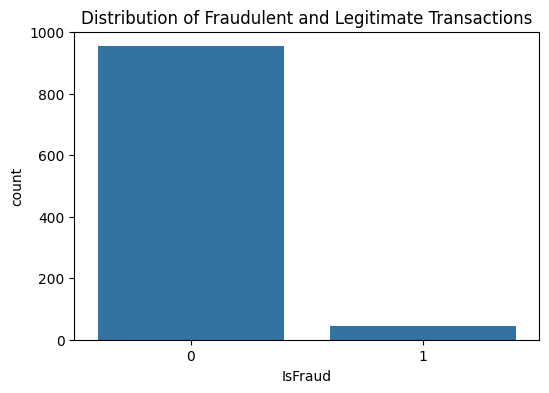

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsFraud', data=df)
plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.show()

##Percentage Distribution of Target Variable

In [ ]:
df['IsFraud'].value_counts(normalize=True) * 100

,proportion
IsFraud,
0,95.4
1,4.6


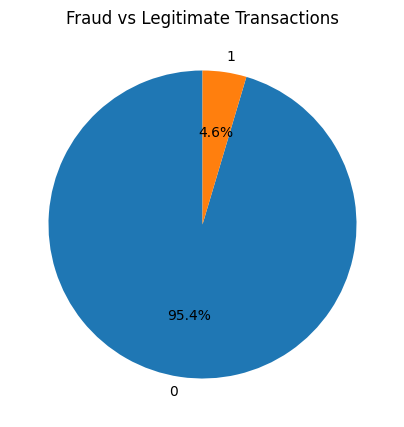

In [ ]:
df['IsFraud'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5),
    startangle=90
)

plt.title("Fraud vs Legitimate Transactions")
plt.ylabel("")
plt.show()

##Numerical Feature Distribution

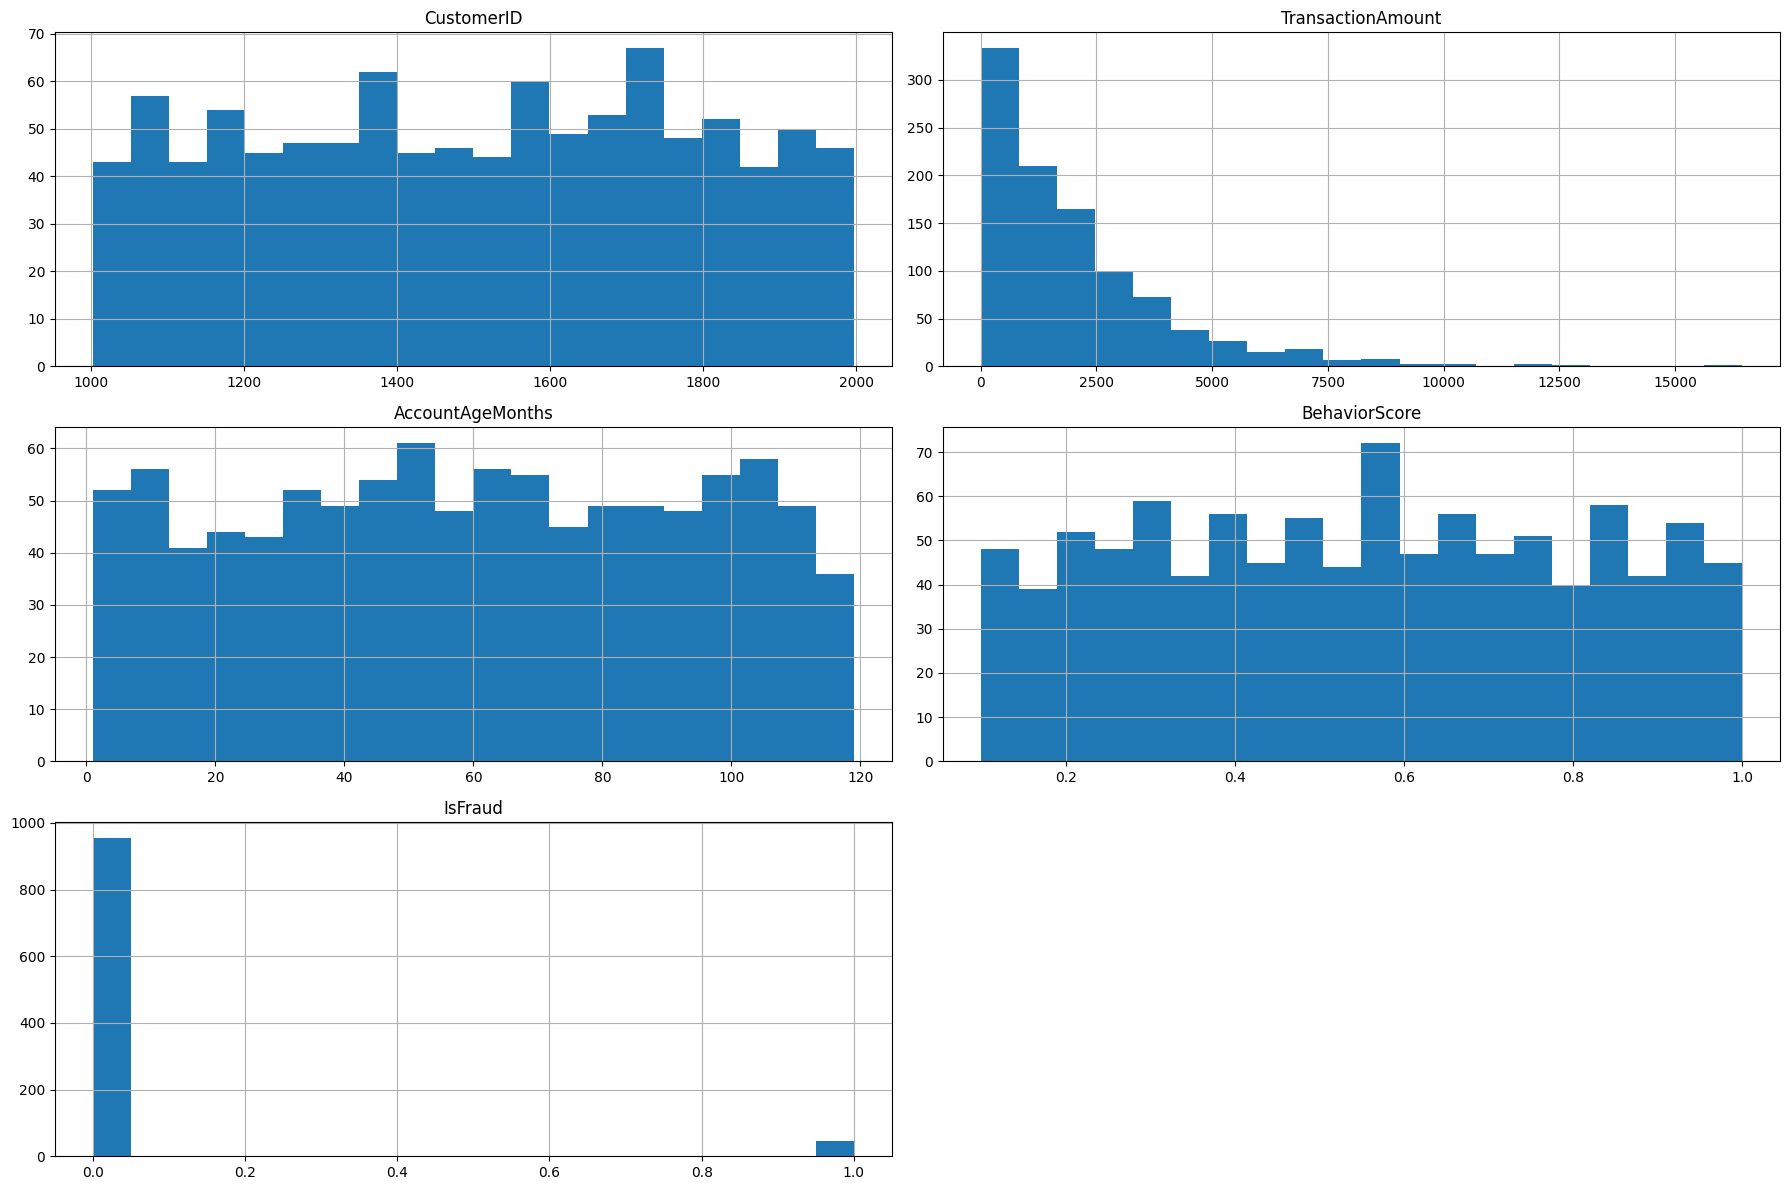

In [ ]:
# Select all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms for numerical columns
df[num_cols].hist(figsize=(18,12), bins=20)

plt.tight_layout()
plt.show()

##Correlation Matrix

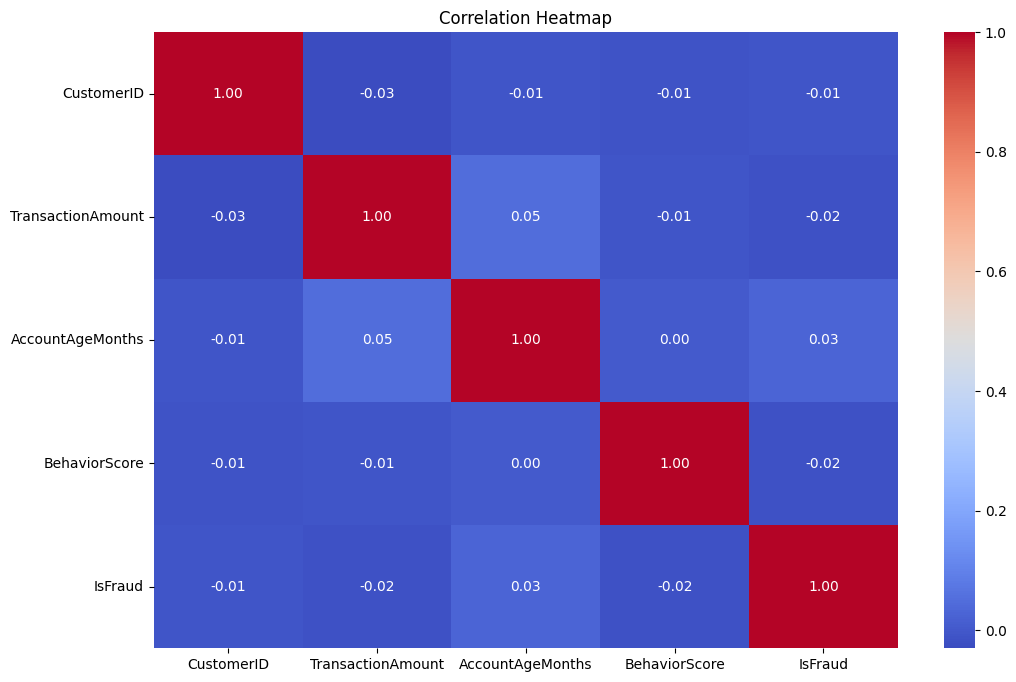

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

##Box Plot for Numerical Features

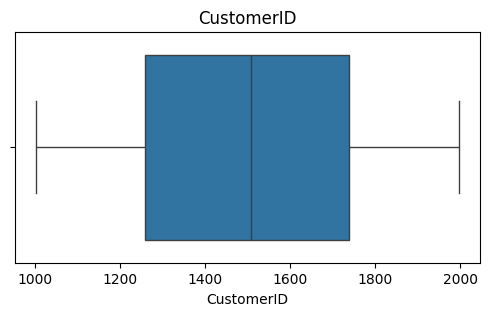

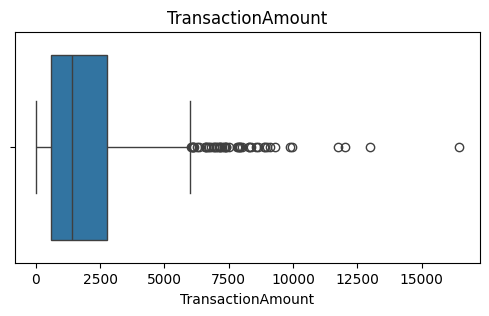

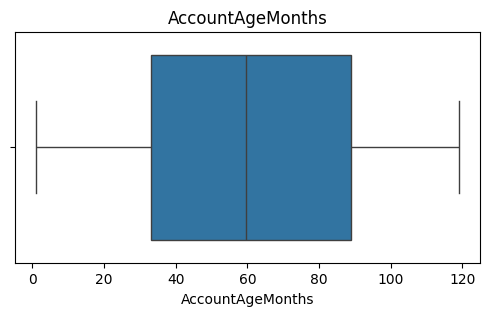

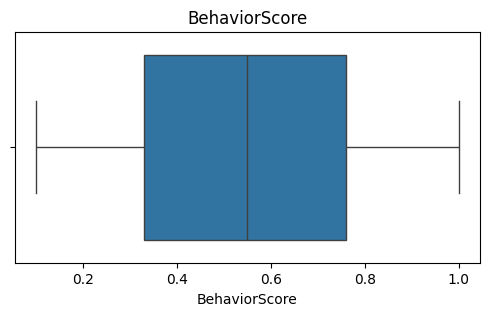

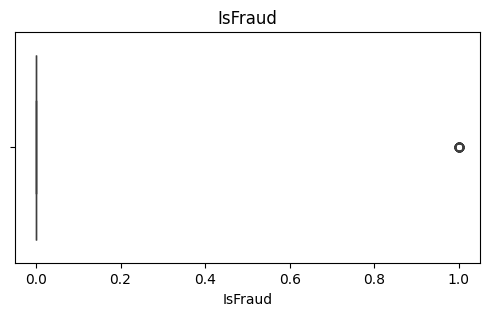

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##Distribution Plot

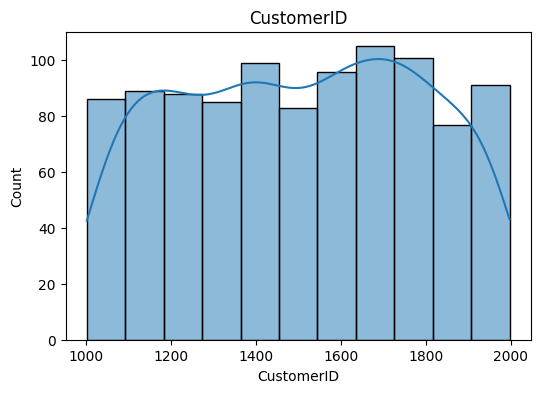

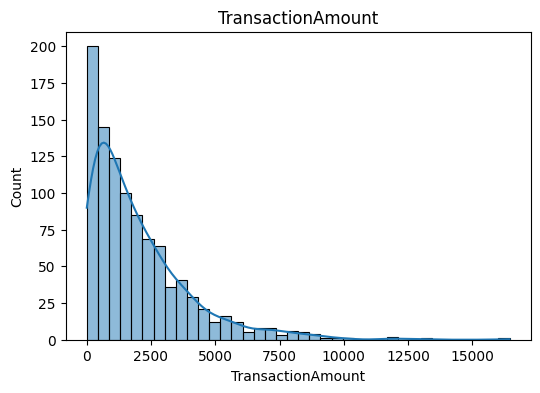

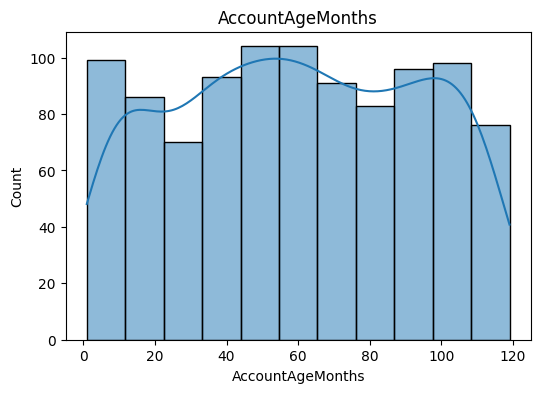

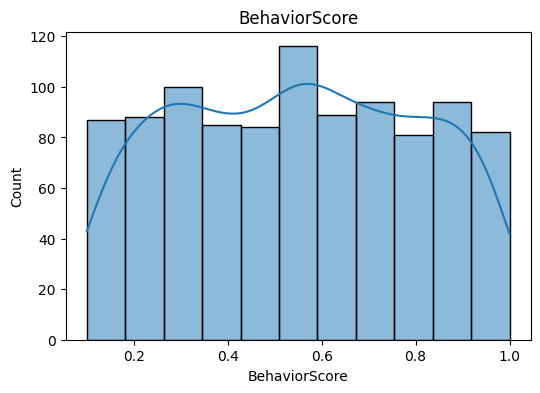

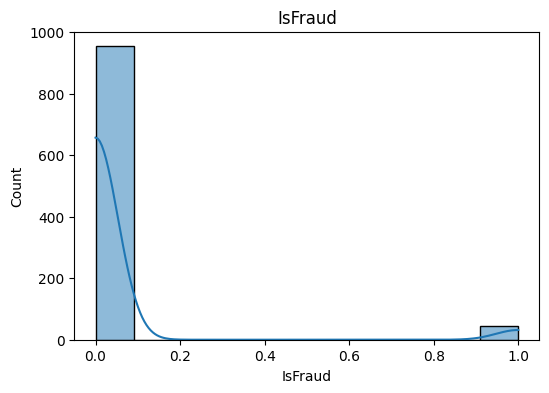

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

##Categorical Feature Analysis

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['TransactionTime', 'Location', 'TransactionType', 'DeviceUsed'], dtype='object')

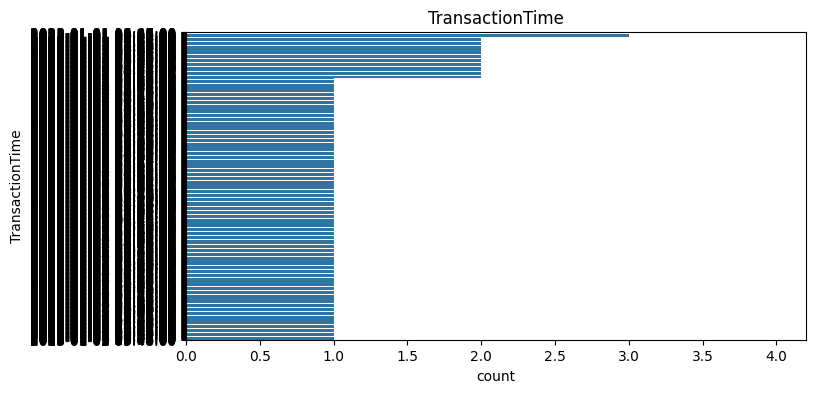

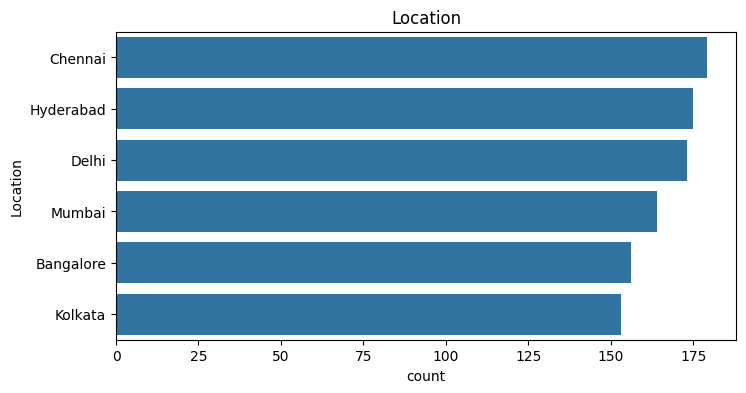

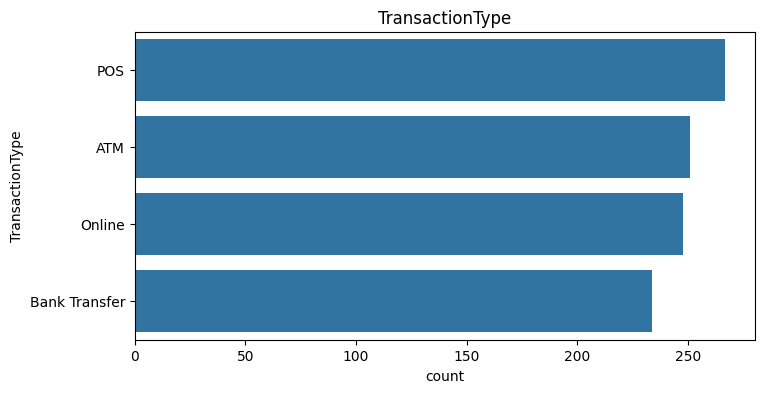

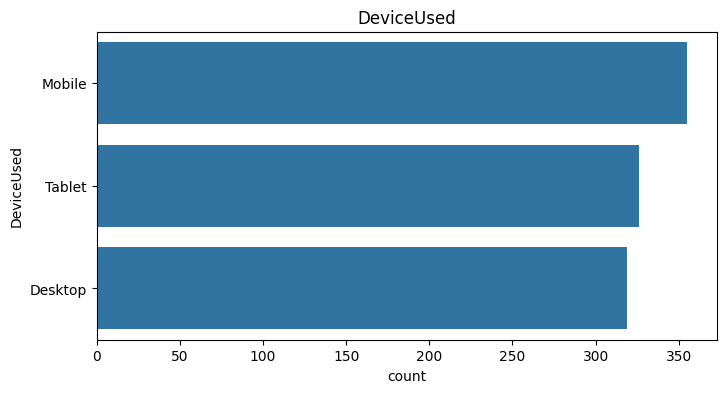

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

##Relationship Between Numerical Features and Targe

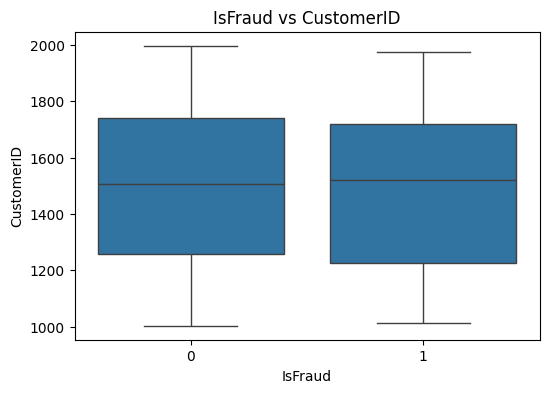

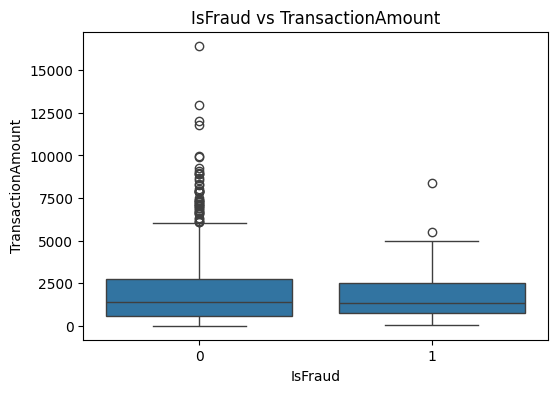

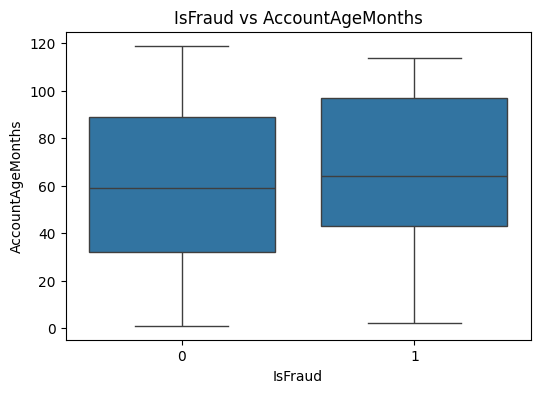

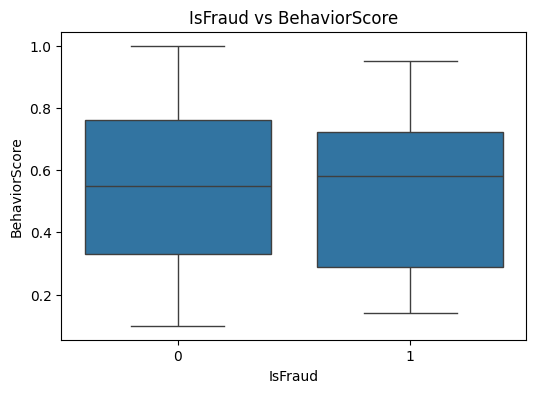

In [ ]:
# Box Plot for Numerical Features vs Target Variable
for col in num_cols:
    if col != 'IsFraud':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='IsFraud', y=col, data=df)
        plt.title(f'IsFraud vs {col}')
        plt.show()

##Pair Plot

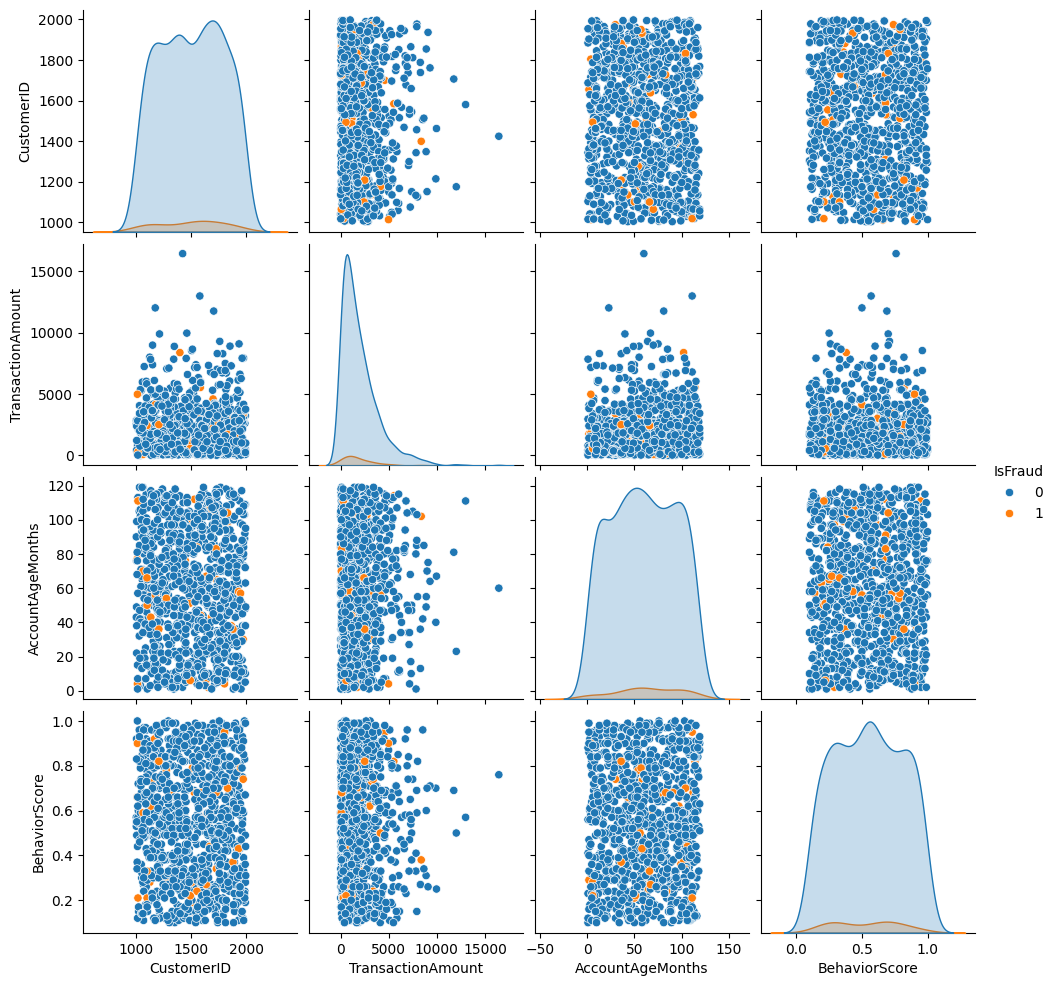

In [ ]:
sns.pairplot(df, hue='IsFraud')
plt.show()

##Observations

The dataset contains both numerical and categorical features.

The target variable indicates whether a transaction is Fraudulent or Legitimate.

Fraud cases are expected to be much fewer than legitimate transactions, indicating class imbalance.

Correlation analysis helps identify strongly related numerical features.

Box plots help detect outliers in transaction amounts and other numerical attributes.

Histograms show the distribution of continuous variables.

Count plots illustrate the frequency distribution of categorical variables.

##Data Preprocessing

In [ ]:
df.isnull().sum()

,0
CustomerID,0
TransactionAmount,0
TransactionTime,0
Location,0
TransactionType,0
AccountAgeMonths,0
BehaviorScore,0
DeviceUsed,0
IsFraud,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
TransactionAmount,0
TransactionTime,0
Location,0
TransactionType,0
AccountAgeMonths,0
BehaviorScore,0
DeviceUsed,0
IsFraud,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ['Location', 'TransactionType', 'DeviceUsed']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1352,1834.26,2023-01-01 13:27:00,0,2,89,0.10,1,0
1,1562,3130.03,2023-01-01 04:52:00,1,0,44,0.63,2,0
2,1828,3030.78,2023-01-01 13:17:00,1,1,97,0.62,2,1
3,1399,493.04,2023-01-01 21:05:00,2,3,13,0.24,1,0
4,1740,1298.36,2023-01-01 03:29:00,1,2,24,0.98,0,0


In [ ]:
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

In [ ]:
X.head()

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed
0,1352,1834.26,2023-01-01 13:27:00,0,2,89,0.10,1
1,1562,3130.03,2023-01-01 04:52:00,1,0,44,0.63,2
2,1828,3030.78,2023-01-01 13:17:00,1,1,97,0.62,2
3,1399,493.04,2023-01-01 21:05:00,2,3,13,0.24,1
4,1740,1298.36,2023-01-01 03:29:00,1,2,24,0.98,0


In [ ]:
y.head()

,IsFraud
0,0
1,0
2,1
3,0
4,0


In [ ]:
# Features and Target
X = df.drop(['IsFraud', 'TransactionTime'], axis=1)
y = df['IsFraud']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (800, 7)
X_test  : (200, 7)
y_train : (800,)
y_test  : (200,)


##Model Building

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

##Model Prediction

In [ ]:
y_pred = model.predict(X_test)

##Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.955


###Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[191   0]
 [  9   0]]


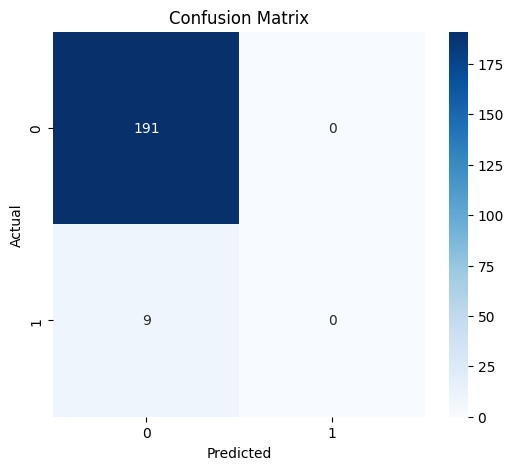

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       191
           1       0.00      0.00      0.00         9

    accuracy                           0.95       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.91      0.95      0.93       200



##Prediction on New Data

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print(prediction)

[0]


##Conclusion

The fraud detection model was successfully developed using the SafeBank transaction dataset.

Data preprocessing included handling missing values, removing duplicates, encoding categorical variables, feature scaling, and splitting the data into training and testing sets.

A Logistic Regression model was trained to classify transactions as Fraudulent or Legitimate.

The model was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

This model can assist banks in identifying potentially fraudulent transactions, reducing financial losses, and improving transaction security.